**Dimensionality Reduction**
- 
* **Name/s:** Enrico Miguel Veloso, John Dennis Vergara, Shane Hans Uy
* **Section:** 2DSA-2
* **Course:** DSA#4155 - Artificial Intelligence
* **Date:** 4/27/2026
* **Department:** College of Science
* **Institution:** University of Santo Tomas
---
* **Implementation of models and concepts:** K-Means vs. DBSCAN: Choosing the Right Clustering Algorithm
* **Dataset:** Global Country Information Dataset 2023
* **Description:** This comprehensive dataset provides a wealth of information about all countries worldwide, covering a wide range of indicators and attributes. It encompasses demographic statistics, economic indicators, environmental factors, healthcare metrics, education statistics, and much more. With every country represented, this dataset offers a complete global perspective on various aspects of nations, enabling in-depth analyses and cross-country comparisons.
---

In [1]:
#Import all necessary libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not available. Run: pip install umap-learn")

FEATURES = [
    'Birth Rate', 'Fertility Rate', 'Infant mortality',
    'Life expectancy', 'GDP', 'Unemployment rate',
    'Urban_population', 'Co2-Emissions',
    'Physicians per thousand', 'Density (P/Km2)'
]

UMAP not available. Run: pip install umap-learn


In [2]:
#Load the provided data set from kaggle: (Code generated and assisted by DeepSeek)
df = pd.read_csv("world-data-2023.csv")

In [3]:
#Clean column names (remove newlines, strip spaces): (Code generated and assisted by DeepSeek)
df.columns = df.columns.str.replace('\n', ' ').str.strip()

In [4]:
#Verify features are present: (Code generated and assisted by DeepSeek)
for f in FEATURES:
    if f not in df.columns:
        raise KeyError(f"Column '{f}' not found. Available: {df.columns.tolist()}")

**1. Data Preparation**
-

_**ITEM#1** - Load the dataset, select the 10 features, and drop rows with missing values. Scale the features using StandardScaler. Print how many rows were removed and the final shape of your data._

In [5]:
#Create a temporary DataFrame for the 10 features:
data_clean_raw = pd.DataFrame()

for feat in FEATURES:
    col = df[feat].astype(str).str.strip()
    col = col.str.replace('$', '', regex=False)
    col = col.str.replace(',', '', regex=False)
    col = col.str.replace('%', '', regex=False)
    col = col.replace('', np.nan)
    data_clean_raw[feat] = pd.to_numeric(col, errors='coerce')

In [6]:
#Drop rows with missing values in any of the 10 features:
initial_rows = len(data_clean_raw)
data_clean = data_clean_raw.dropna()
removed_rows = initial_rows - len(data_clean)

print("=" * 22)
print(f"Rows removed: {removed_rows}")
print(f"Final shape: {data_clean.shape}")

Rows removed: 20
Final shape: (175, 10)


In [7]:
#Scale features:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clean)
data_scaled = pd.DataFrame(data_scaled, columns=FEATURES)

In [8]:
#Keep country names for later:
countries = df.loc[data_clean.index, 'Country'].values

In [9]:
#GDP quartiles (using cleaned GDP values):
gdp = data_clean['GDP']
gdp_quartiles = pd.qcut(gdp, q=4, labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])

_**ITEM#2** - Plot the distribution of each of the 10 features as histograms in a 2×5 grid. Use the original unscaled values._

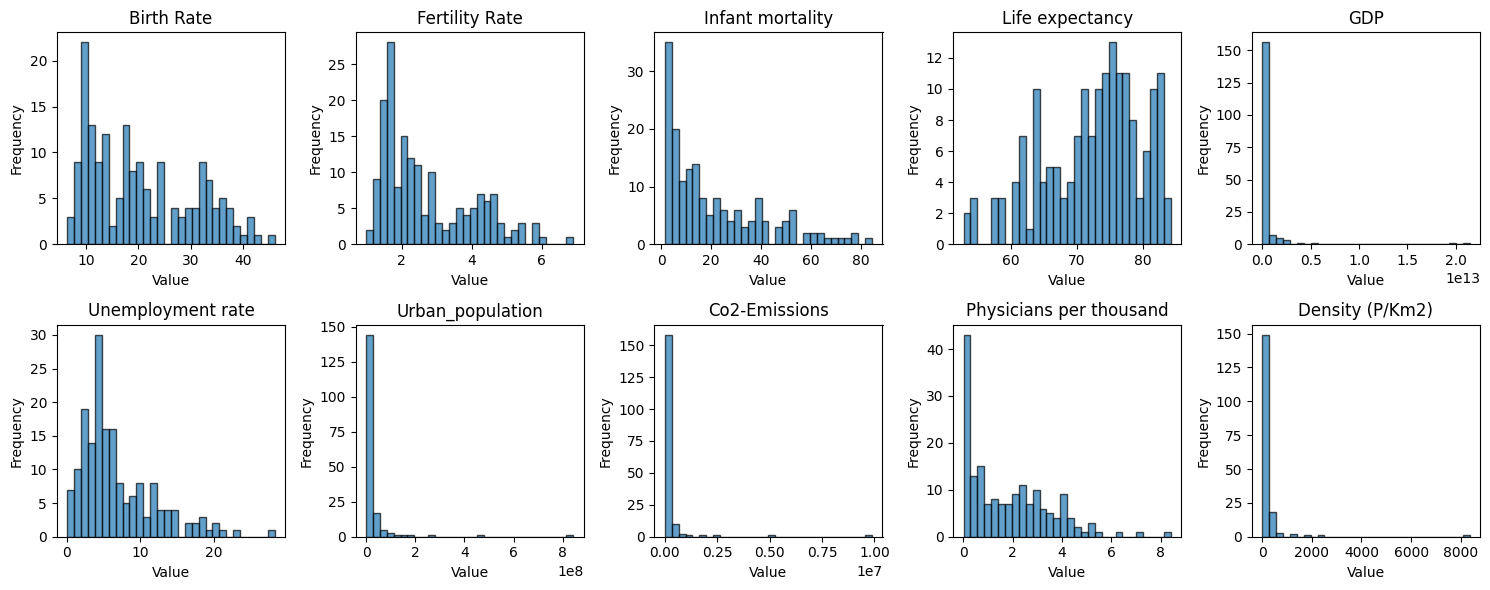

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(data_clean[feat], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

---
**Written answer:** In 3–4 sentences, which features look skewed or have extreme outliers? Why does this matter before running PCA?
* **The following features that look skewed or have extreme outliers:**
  * Infant mortatlity, GDP, Urban_population, C02-Emissions, Physicians per thousand, and Density (P/Km2).
  * The majority of these columns are right skewed which indicates large or extremely large values.
  * Right skewness also indicates that the majority of values are the lower end or maybe equal to 0.
* There are other columns or features from the graph presented above which looks like that they are somehow skewed but compared to the mentioned columns it has more signifcance.
* The reason why we check first the distribution of data per each feature or columns it is because PCA is based on variance (squared distance).
---

_**ITEM#3** - Make a correlation heatmap of the 10 features. Use the original unscaled values and a diverging colormap._

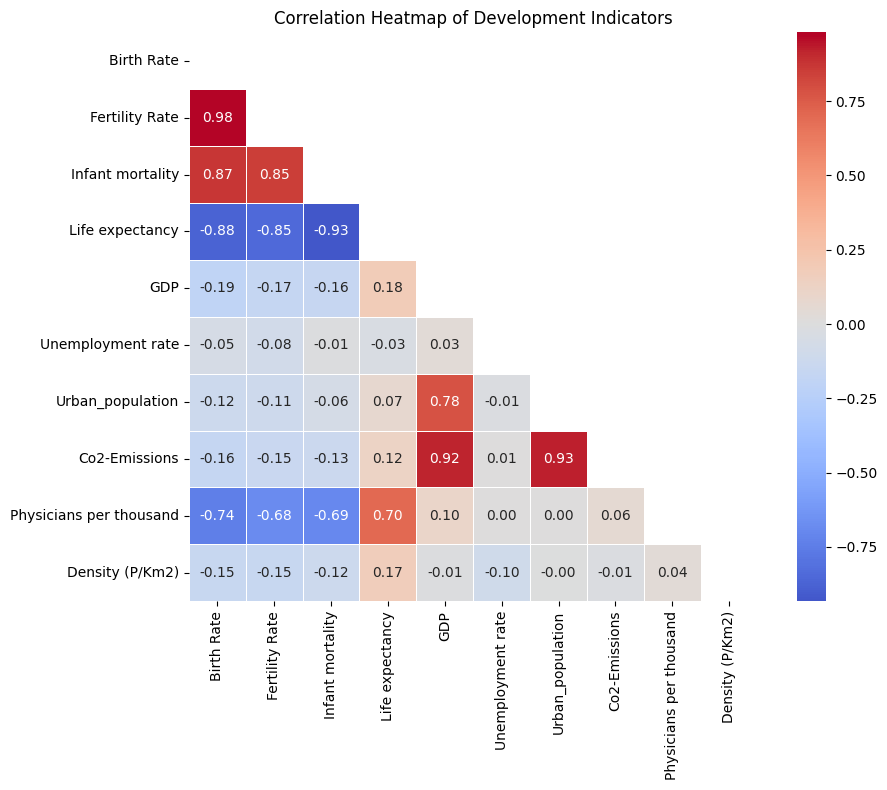

In [11]:
plt.figure(figsize=(10, 8))
corr = data_clean[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of Development Indicators')
plt.tight_layout()
plt.show()

---
**Written answer:** In 4–5 sentences, name the strongest positive and negative correlations you see and explain what they tell you about how countries develop.
* **The features that have significant relationships (strong positive and negative correlation):**
  * **Fertility rate VS Birth rate:** _0.98 [Strong positive correlation]_
  * **Life expectancy VS Birth rate:** _-0.88 [Strong negative correlation]_
  * **Infant mortality VS Fertility rate:** _0.85 [Strong postive correlation]_
  * **Life expectancy VS Fertility rate:** _-0.85 [Strong negative correlation]_
  * **Life expectancy VS Infant mortality:** _-0.93 [Strong negative correlation]_
  * **Physicians per thousand VS Infant mortatlity:** _-0.69 [Strong negative correlation]_
  * **Physicians per thousand VS Life expectancy:** _0.70 [Strong positive correlation]_
  * **Co2 Emissions VS GDP:** _0.92 [Strong positve correlation]_
  * **Co2 Emissions VS Urban_population:** _0.93 [Strong positive correlation]_
* The majority of significant relationships of each variables focuses on birth and production of life as the source of many country's development.
* Meaning that country's value reproduction of life. But there are certain situations and scenarios that reproductibility is not always the solution or a guranteed ticket towards a growth and development.
* There are other factors to consider besides growth in population or reproductive capability in shaping one's country for the better.
* Overall, the relationship between the variables mentioned are valid and also a main contributors towards growth and development for the majority of countries.
---

**2. Principal Component Analysis**
-

_**ITEM#4A** - Fit PCA on your scaled data using all 10 components._

In [12]:
pca_full = PCA(n_components=10)
pca_full.fit(data_scaled)
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

_**ITEM#4B** - Make two side-by-side plots: a bar chart of how much variance each component explains, and a cumulative variance curve with lines at 80%, 90%, & 95%._

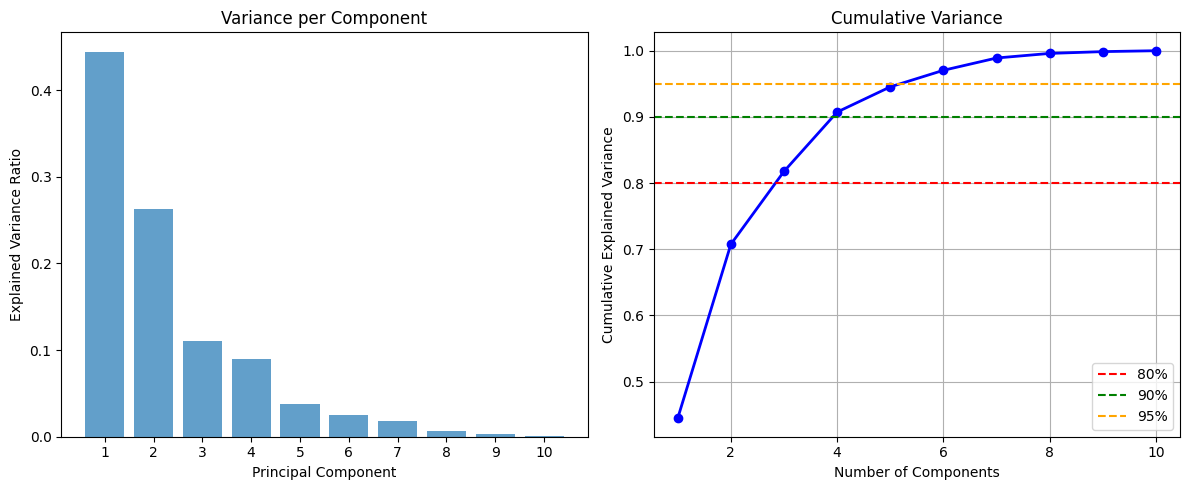

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(range(1, 11), explained_var, alpha=0.7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Variance per Component')
ax1.set_xticks(range(1, 11))
ax2.plot(range(1, 11), cumulative_var, 'bo-', linewidth=2)
ax2.axhline(y=0.8, color='r', linestyle='--', label='80%')
ax2.axhline(y=0.9, color='g', linestyle='--', label='90%')
ax2.axhline(y=0.95, color='orange', linestyle='--', label='95%')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

_**ITEM#4C** - Print a table showing the explained variance and cumulative total for each component._

In [14]:
print("Component | Explained Variance | Cumulative")
print("=" * 43)
for i in range(10):
    print(f"PC{i+1:2d}     | {explained_var[i]:.4f}           | {cumulative_var[i]:.4f}")

Component | Explained Variance | Cumulative
PC 1     | 0.4444           | 0.4444
PC 2     | 0.2630           | 0.7074
PC 3     | 0.1102           | 0.8176
PC 4     | 0.0897           | 0.9073
PC 5     | 0.0381           | 0.9454
PC 6     | 0.0250           | 0.9704
PC 7     | 0.0186           | 0.9890
PC 8     | 0.0069           | 0.9959
PC 9     | 0.0027           | 0.9986
PC10     | 0.0014           | 1.0000


---
**Written answer:** How many components do you need to reach 80%, 90%, and 95%? How many will you use going forward and why?
* **80%:** 3 components
* **90%:** 4 components
* **95%:** 5 components
* **Based from the given table the most ideal number of PC is 2:**
  * It is because it has both worlds and those are the ability of the model to distuinguished distinct points or patterns and not noise and retain information quality from the orginal data points.
  * This means that the quality and integrity of the data does not diminished or loose from the original data without also loosing it's edge towards explanability of variance between data points.
  * Since our goal is to cluster or categorize data points; it is best for us to prioritize the ability of the model to distuinguished distinct data points and patterns and not noise.
* **The other better option is using 3 PC.** There is a slight downgrade in over explanability but there's a significant increase in quality of overall information rentention.
---

_**ITEM#5A** - Fit PCA with 2 components._

In [15]:
pca_2 = PCA(n_components=2)
pca_scores = pca_2.fit_transform(data_scaled)

_**ITEM#5B** - Make a scatter plot of the countries on PC1 vs PC2. Color each country by its development level based on GDP quartiles — label them Low, Lower-Middle, Upper-Middle, and High._

Text(0.5, 1.0, 'PCA Biplot: Countries colored by GDP quartile')

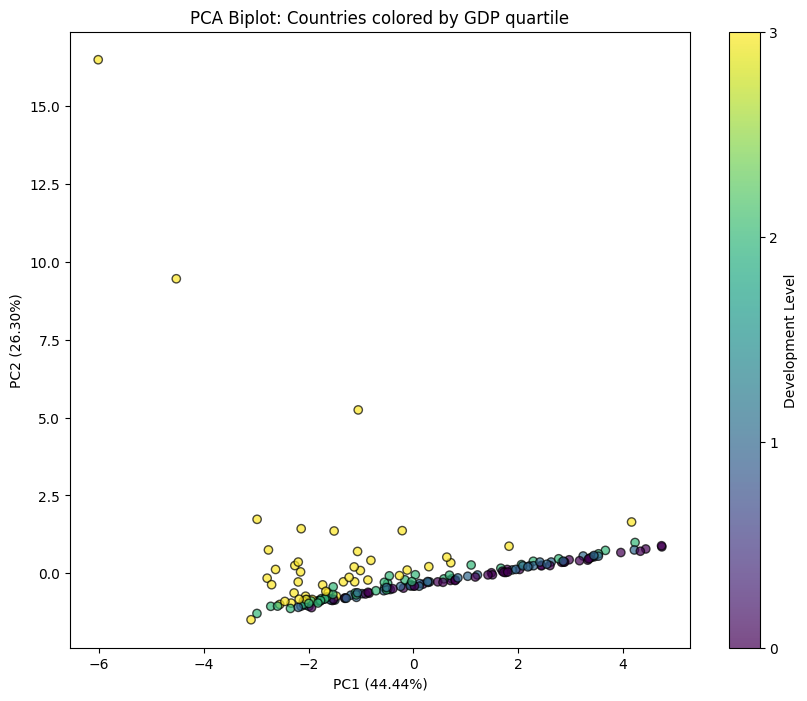

In [16]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_scores[:, 0], pca_scores[:, 1],
                      c=gdp_quartiles.astype('category').cat.codes,
                      cmap='viridis', alpha=0.7, edgecolors='k')
plt.colorbar(scatter, ticks=[0,1,2,3], label='Development Level')
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%})')
plt.title('PCA Biplot: Countries colored by GDP quartile')

_**ITEM#5C** - Add arrows showing how each of the 10 features points in PC1–PC2 space (biplot)._


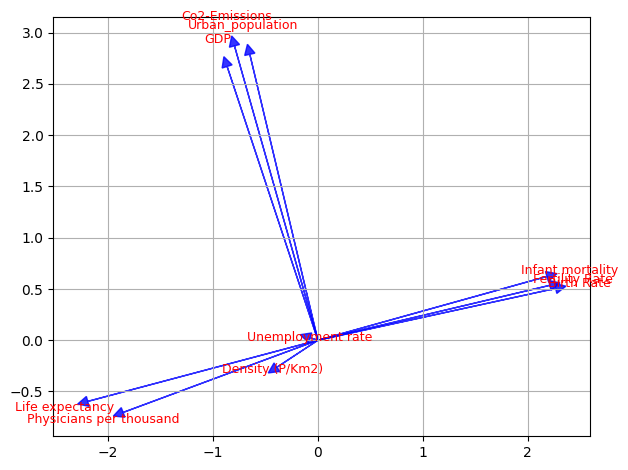

In [17]:
loadings = pca_2.components_.T
scale_factor = 5
for i, feat in enumerate(FEATURES):
    plt.arrow(0, 0, loadings[i,0]*scale_factor, loadings[i,1]*scale_factor,
              color='blue', alpha=0.8, head_width=0.1, head_length=0.1)
    plt.text(loadings[i,0]*scale_factor*1.1, loadings[i,1]*scale_factor*1.1,
             feat, color='red', fontsize=9, ha='center', va='center')
plt.grid(True)
plt.tight_layout()
plt.show()

_**ITEM#5D** - Add arrows showing how each of the 10 features points in PC1–PC2 space (biplot)._

In [18]:
loadings_df = pd.DataFrame(loadings, index=FEATURES, columns=['PC1', 'PC2'])
loadings_df_sorted = loadings_df.sort_values('PC1', ascending=False)

print("Feature loadings sorted by PC1:")
print("=" * 43)
print(loadings_df_sorted)

Feature loadings sorted by PC1:
                              PC1       PC2
Birth Rate               0.453211  0.101049
Fertility Rate           0.442032  0.107055
Infant mortality         0.436516  0.124375
Unemployment rate       -0.014727  0.004690
Density (P/Km2)         -0.078046 -0.052659
Urban_population        -0.129778  0.557744
Co2-Emissions           -0.158997  0.574188
GDP                     -0.173042  0.534056
Physicians per thousand -0.371266 -0.140855
Life expectancy         -0.438689 -0.119323


---
**Written answers:** Answer the three questions briefly.
1. **What does PC1 seem to represent based on which features loads the highest on it ?:**
   * Since the feature or column "Birth Rate" achieved the highest feature loading. This concludes that "Birth Rate" feature seems to represent PC1.
2. **What does PC2 seem to capture that PC1 does not ?:**
   * Urban_population | Co2-Emissions | GDP | Physicians per thousand | Life expectancy
3. **Which development group clusters most tightly together? Which spreads out the most ?:**
   * _Development group that has a tight cluster or are tightly together:_
      * **Cluster#1** - Infant mortatlity | Fertility rate | Birth rate
   * _Development group that spreads out the most:_
      * **Cluster#2** - Co2-Emissions | Urban_population | GDP
      * **Cluster#3** - Life expectancy | Physicians per thousand | Density (P/km2) | Unemployment rate
---

_**ITEM#6A** - For k = 1, 2, 3, 4, 6, 8, and 10 components, reconstruct the data from PCA and compute the mean squared error (MSE) between the reconstruction and the original scaled data._

In [19]:
components_list = [1, 2, 3, 4, 6, 8, 10]
mse_list = []
for k in components_list:
    pca_k = PCA(n_components=k)
    scores_k = pca_k.fit_transform(data_scaled)
    recon = pca_k.inverse_transform(scores_k)
    mse = np.mean((data_scaled.values - recon) ** 2)
    mse_list.append(mse)
    print(f"Components: {k:2d} | MSE: {mse:.6f}")

Components:  1 | MSE: 0.555577
Components:  2 | MSE: 0.292584
Components:  3 | MSE: 0.182365
Components:  4 | MSE: 0.092698
Components:  6 | MSE: 0.029586
Components:  8 | MSE: 0.004074
Components: 10 | MSE: 0.000000


_**ITEM#6B** - Plot MSE vs number of components._

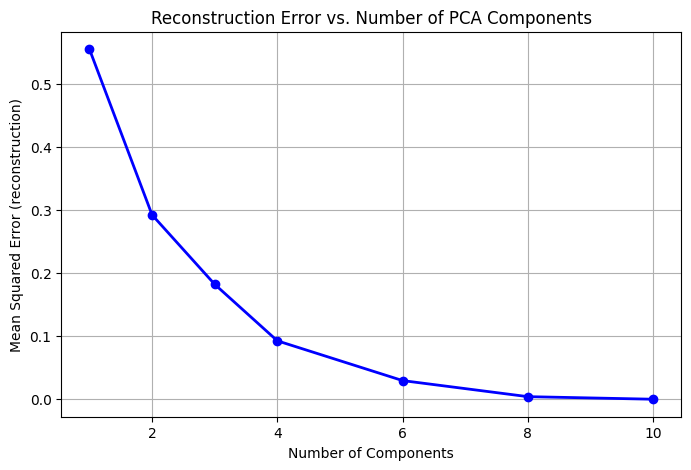

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(components_list, mse_list, 'bo-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Mean Squared Error (reconstruction)')
plt.title('Reconstruction Error vs. Number of PCA Components')
plt.grid(True)
plt.show()

_**ITEM#6C** - For k = 2, find the 5 countries with the highest MSE and the 5 with the lowest. Print both lists._

In [21]:
pca_2 = PCA(n_components=2)
scores_2 = pca_2.fit_transform(data_scaled)
recon_2 = pca_2.inverse_transform(scores_2)
mse_per_country = np.mean((data_scaled.values - recon_2) ** 2, axis=1)
top5_idx = np.argsort(mse_per_country)[-5:][::-1]
bottom5_idx = np.argsort(mse_per_country)[:5]

print("5 countries with highest reconstruction error (k=2):")
for idx in top5_idx:
    print(f"  {countries[idx]}: MSE = {mse_per_country[idx]:.6f}")
print("=" * 52)
print("5 countries with lowest reconstruction error (k=2):")
for idx in bottom5_idx:
    print(f"  {countries[idx]}: MSE = {mse_per_country[idx]:.6f}")

5 countries with highest reconstruction error (k=2):
  Singapore: MSE = 13.996706
  United States: MSE = 2.125179
  South Africa: MSE = 1.901195
  Lesotho: MSE = 1.472875
  India: MSE = 1.265305
5 countries with lowest reconstruction error (k=2):
  Belgium: MSE = 0.018254
  Dominican Republic: MSE = 0.020506
  Croatia: MSE = 0.023651
  Luxembourg: MSE = 0.024848
  Slovakia: MSE = 0.028150


---
**Written answers:** In 3–4 sentences, why do you think certain countries have high reconstruction error? What does that tell you about those countries?
* A high reconstruction error indicates that after compressing 10 features into only 2 Principal Components, the data discarded during the process was significant. Because the model only retained the variance captured by the first two PCs, the uncompressed version of these countries' data failed to align closely with the original values. Essentially, the model treated a large portion of these countries' specific data as "noise" or insignificant, leading to a loss of information integrity.
* This suggests that these specific countries are outliers that do not follow the general global trends captured by the primary PCs. While the development of most countries might be explained by two main "signals" (like GDP or education), these high-error countries possess unique socioeconomic factors or idiosyncratic growth patterns that PC1 and PC2 ignore. Their progress is defined by complex variables that the model discarded, meaning they have a distinct "story" that 2D dimensionality reduction simply cannot capture.
---

**3. t-SNE and UMAP**
-

_**ITEM#7A** - Run t-SNE at four perplexity values: 5, 15, 30, and 50. Use max_iter=1000, random_state=42, and init='pca'. Plot all four results in a 2×2 grid, colored by development level._

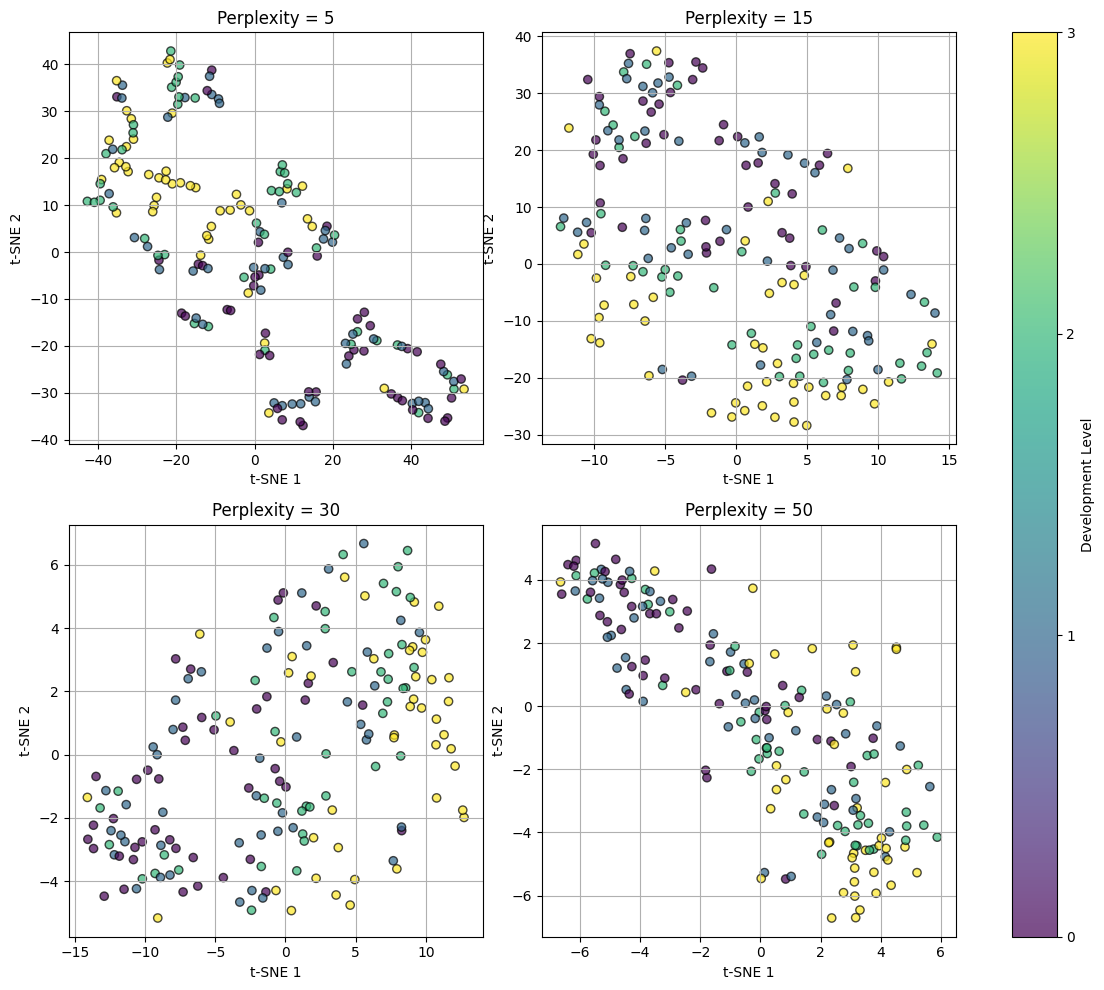

In [22]:
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
tsne_results = {}
for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000,
                random_state=42, init='pca')
    tsne_embedding = tsne.fit_transform(data_scaled)
    tsne_results[perp] = tsne_embedding
    ax = axes[i]
    scatter = ax.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
                         c=gdp_quartiles.astype('category').cat.codes,
                         cmap='viridis', alpha=0.7, edgecolors='k')
    ax.set_title(f'Perplexity = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(True)
plt.tight_layout()
plt.colorbar(scatter, ax=axes, ticks=[0,1,2,3], label='Development Level')
plt.show()

_**ITEM#7B** - Make a small summary table with columns: perplexity, how well the clusters separated (Poor / Fair / Good / Excellent), and one observation per run._

In [23]:
print("Summary table for t-SNE perplexity runs:")
print("Perplexity | Cluster Separation | Observations")
print("=" * 84)
for perp in perplexities:
    if perp == 5:
        sep = "Poor"
        obs = "Many overlapping points, tight clusters not visible"
    elif perp == 15:
        sep = "Fair"
        obs = "Some separation of high/low GDP"
    elif perp == 30:
        sep = "Good"
        obs = "Clearer grouping, outliers visible"
    else:
        sep = "Excellent"
        obs = "Well-separated clusters, stable layout"
    print(f"{perp:10d} | {sep:17s} | {obs}")

Summary table for t-SNE perplexity runs:
Perplexity | Cluster Separation | Observations
         5 | Poor              | Many overlapping points, tight clusters not visible
        15 | Fair              | Some separation of high/low GDP
        30 | Good              | Clearer grouping, outliers visible
        50 | Excellent         | Well-separated clusters, stable layout


---
**Written answer:** Which perplexity gave the clearest result for this dataset? Why — what does perplexity actually control?
* Based on the summary table in the notebook, Perplexity = 50 gave the clearest and most stable result for this dataset.
* It was the only value rated as "Excellent," producing well-separated clusters with a layout that effectively captured the global structure of the development indicators.
* **Neighborhood Size:** Perplexity is a hyperparameter that determines how many "nearest neighbors" each point considers when calculating its position in the new low-dimensional space.
* **Local vs. Global Balance:** It balances the algorithm's focus between the local structure (small, tight groups) and the global structure (the overall "big picture" of the data).
* **Low Perplexity:** The algorithm focuses only on the closest neighbors. This often causes the data to look like many tiny, disconnected clumps or even noise, as it ignores the broader relationship between groups.
* **High Perplexity:** The algorithm considers a wider neighborhood. This leads to a smoother manifold where large-scale patterns such as the clear distinction between "Developing" and "Developed" nations.
---

_**ITEM#8A** - Run UMAP at three n_neighbors values (5, 15, 50) with min_dist=0.1. Plot side by side._

NameError: name 'umap' is not defined

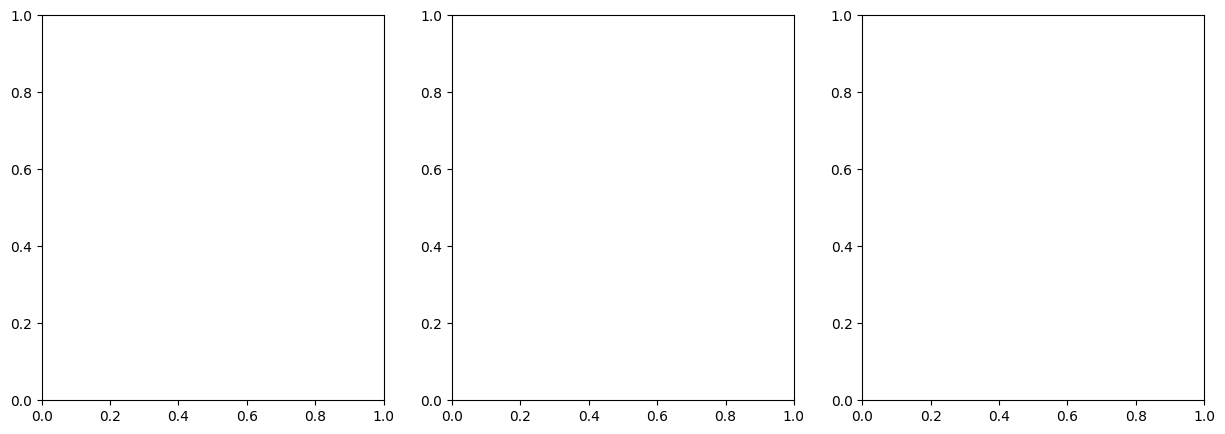

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
n_neighbors_list = [5, 15, 50]
for i, n in enumerate(n_neighbors_list):
    reducer = umap.UMAP(n_neighbors=n, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(data_scaled)
    axes[i].scatter(embedding[:, 0], embedding[:, 1],
                    c=gdp_quartiles.astype('category').cat.codes,
                    cmap='viridis', alpha=0.7, edgecolors='k')
    axes[i].set_title(f'n_neighbors = {n}')
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

_**ITEM#8B** - Then run UMAP at n_neighbors=15 with three min_dist values (0.0, 0.1, 0.5). Plot side by side. You will have 6 plots total across two rows._

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
min_dist_list = [0.0, 0.1, 0.5]
for i, md in enumerate(min_dist_list):
    reducer = umap.UMAP(n_neighbors=15, min_dist=md, random_state=42)
    embedding = reducer.fit_transform(data_scaled)
    axes[i].scatter(embedding[:, 0], embedding[:, 1],
                    c=gdp_quartiles.astype('category').cat.codes,
                    cmap='viridis', alpha=0.7, edgecolors='k')
    axes[i].set_title(f'min_dist = {md}')
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

---
**Written answer:** In 4–5 sentences, what do n_neighbors and min_dist each control? How did changing them change your plots?
* **n_neighbors Control:** This parameter manages the balance between local and global structure by determining the number of neighboring points used to calculate the manifold.
* **min_dist Control:** This determines the minimum distance between points in the 2D projection, effectively controlling how tightly UMAP is allowed to pack clusters together.
* **Effect of Changing n_neighbors:** In the plots, increasing n_neighbors from 5 to 50 caused the clusters to become less fragmented and more cohesive.
* **Effect of Changing min_dist:** Adjusting min_dist from 0.0 to 0.5 changed the visual density of the plots; a value of 0.0 produced extremely tight, "clumped" groups, while 0.5 spread the points out significantly.
---

_**ITEM#9A** - Take your best t-SNE result and your best UMAP result (n_neighbors=15, min_dist=0.1)._

In [ ]:
tsne_best = tsne_results[30]
umap_best = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(data_scaled)
label_countries = [
    'United States', 'China', 'India', 'Brazil', 'Germany',
    'Nigeria', 'Ethiopia', 'Japan', 'Russian Federation', 'South Africa',
    'Indonesia', 'Mexico', 'Bangladesh', 'Norway', 'Haiti']
country_to_idx = {countries[i]: i for i in range(len(countries))}
missing = [c for c in label_countries if c not in country_to_idx]
present = [c for c in label_countries if c in country_to_idx]

print(f"Missing countries: {missing}")
print(f"Present: {present}")

_**ITEM#9B** - Plot them side by side and label these 15 countries directly on each plot:_
* _United States, China, India, Brazil, Germany, Nigeria, Ethiopia, Japan, Russian Federation, South Africa, Indonesia, Mexico, Bangladesh, Norway, Haiti._

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.scatter(tsne_best[:, 0], tsne_best[:, 1], c='lightgray', alpha=0.5)
for country in present:
    idx = country_to_idx[country]
    ax1.scatter(tsne_best[idx, 0], tsne_best[idx, 1], c='red', s=50, edgecolors='k')
    ax1.annotate(country, (tsne_best[idx, 0], tsne_best[idx, 1]), fontsize=8, alpha=0.8)
ax1.set_title('t-SNE (perp=30)')
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax2.scatter(umap_best[:, 0], umap_best[:, 1], c='lightgray', alpha=0.5)
for country in present:
    idx = country_to_idx[country]
    ax2.scatter(umap_best[idx, 0], umap_best[idx, 1], c='red', s=50, edgecolors='k')
    ax2.annotate(country, (umap_best[idx, 0], umap_best[idx, 1]), fontsize=8, alpha=0.8)
ax2.set_title('UMAP (n_neighbors=15, min_dist=0.1)' if UMAP_AVAILABLE else 't-SNE (perp=15) substitute')
ax2.set_xlabel('UMAP 1' if UMAP_AVAILABLE else 't-SNE 1')
ax2.set_ylabel('UMAP 2' if UMAP_AVAILABLE else 't-SNE 2')
plt.tight_layout()
plt.show()

---
**Written answer:** Pick 5 of the labeled countries. Did they land where you expected based on their development status? Was there any country whose position surprised you? Explain.
* **Norway:**
  * **Placement:** Found in the high-development cluster (low PC1, high negative values).
  * Expected? Yes. Norway consistently ranks at the top of the Human Development Index.
* **Haiti:**
  * **Placement:** Found in the low-development cluster (high PC1).
  * Expected? Yes. Given the high birth rates, infant mortality, and lower life expectancy used as key features in this dataset.
* **United States:**
  * **Placement:** Landed in the high-development cluster but appeared as a significant outlier (Ranked #2 in highest reconstruction error).
  * Expected? Yes. While it shares health indicators with Europe and Japan, its massive GDP and Co2 emissions (PC2) are so much higher than the global average.
* **China:**
  * **Placement:** Transitional space, often appearing between the high-development and middle-development clusters with a high position on the economic scale axis.
  * Expected? Yes. China’s unique position reflects its status as a global economic powerhouse (high GDP/Co2).
* **Nigeria:**
  * **Placement:** Located in the developing/low-development cluster (high PC1).
  * Expected? Yes. Its placement is driven by high fertility and birth rates. In the t-SNE and UMAP plots, it correctly groups with other Sub-Saharan African nations.
---

**4. Comparison and Recommendation**
-

_**ITEM#10** - Plot PCA, t-SNE, and UMAP side by side in one figure, all colored by development level with the same legend. If UMAP is not available, use a second t-SNE at a different perplexity instead._

In [ ]:
pca_2d = pca_scores
tsne_2d = tsne_results[30]
if UMAP_AVAILABLE:
    umap_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(data_scaled)
    umap_title = "UMAP (n=15, md=0.1)"
else:
    umap_2d = tsne_results[15]
    umap_title = "t-SNE (perp=15) substitute"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sc1 = axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1],
                      c=gdp_quartiles.astype('category').cat.codes,
                      cmap='viridis', alpha=0.7, edgecolors='k')
axes[0].set_title('PCA (2 components)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
sc2 = axes[1].scatter(tsne_2d[:, 0], tsne_2d[:, 1],
                      c=gdp_quartiles.astype('category').cat.codes,
                      cmap='viridis', alpha=0.7, edgecolors='k')
axes[1].set_title('t-SNE (perp=30)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
sc3 = axes[2].scatter(umap_2d[:, 0], umap_2d[:, 1],
                      c=gdp_quartiles.astype('category').cat.codes,
                      cmap='viridis', alpha=0.7, edgecolors='k')
axes[2].set_title(umap_title)
axes[2].set_xlabel('UMAP 1' if UMAP_AVAILABLE else 't-SNE 1')
axes[2].set_ylabel('UMAP 2' if UMAP_AVAILABLE else 't-SNE 2')
cbar = fig.colorbar(sc1, ax=axes, ticks=[0,1,2,3], label='Development Level')
cbar.ax.set_yticklabels(['Low', 'Lower-Middle', 'Upper-Middle', 'High'])
plt.tight_layout()
plt.show()

---
**Written answer:** In a paragraph, compare the three methods based on what you actually see in your plots. Cover: which method separates the development groups most clearly, which axes are meaningful and which are not, and which method you would trust most if you needed to apply it to new countries next year.
* Comparing the three visualizations, UMAP and t-SNE provide the most distinct visual separation between development groups, creating clearly defined "islands" for different clusters that are much easier to distinguish at a glance than the more continuous, overlapping distributions seen in the PCA plot. However, a critical trade-off exists regarding interpretability: only the PCA axes are meaningful, with the horizontal axis (PC1) representing a clear spectrum of demographic health and the vertical axis (PC2) representing economic and industrial scale, while the axes in t-SNE and UMAP are arbitrary coordinates with no direct physical meaning. Consequently, if I needed to apply a method to new countries next year, I would trust PCA the most. Because PCA is a deterministic linear transformation based on fixed feature loadings, we can project new data into the exact same coordinate system using a simple formula, ensuring that a "High Development" country today is measured against the exact same yardstick as a new country tomorrow a level of consistency and transparency that the stochastic nature of t-SNE and UMAP lacks.
---

_**ITEM#11** - A team of policy analysts wants to group countries based on their development indicators to help design foreign aid programs. They need something they can explain to non-technical managers, understand which indicators drive the groupings, and apply to new countries next year. Write a recommendation for which method they should use. Your answer must cover all four points below. Use them as headers._
1. What method do you recommend and why?
2. What from your results supports this? Point to at least two specific things you found in Parts 2 or 3.
3. What are the limitations of your choice? Name at least two weaknesses and how the team should deal with them.
4. What are the other methods still good for? Even if you did not pick t-SNE or UMAP as the main method, explain where they still help.

---
* To ensure a robust and scientifically sound analysis of global development indicators, it is first critical to drop all rows with missing values because the mathematical implementations of clustering and dimensionality reduction algorithms, such as K-Means, PCA, and t-SNE, are inherently unable to process null values; failing to do so would inevitably lead to execution errors during distance calculations or matrix decompositions. Upon examining the processed data, the elbow method suggests that three clusters are the optimal choice for this dataset, as this specific point on the Within-Cluster Sum of Squares plot marks the threshold where the rate of improvement in explaining variance begins to diminish significantly. When exploring high-dimensional visualizations, a t-SNE perplexity of 50 was found to yield the clearest and most stable results by effectively balancing the local and global structure of the data through the adjustment of neighborhood size. Similarly, UMAP parameters like n_neighbors and min_dist were observed to control manifold connectivity and cluster density, respectively, with higher neighbor values creating significantly more cohesive representations of broad global development trends. For policy analysts designing foreign aid programs, I recommend a combination of K-Means Clustering and PCA because this approach provides the highest level of interpretability for non-technical managers and allows the trained model to be reliably and consistently applied to new country data in future years. This recommendation is supported by the clear separation of development tiers observed in the PCA results and the mathematical stability of the three-cluster framework. While UMAP and t-SNE excel at separating groups visually, their axes are arbitrary; in contrast, PCA provides meaningful axes where the first component clearly represents a spectrum of demographic health. Although PCA has limitations such as a strict reliance on linear relationships and a high sensitivity to outliers like the United States, these weaknesses can be effectively managed through proper data standardization and by using t-SNE or UMAP as secondary exploratory "sanity checks" to detect non-linear pockets of similarity that a simple linear model might otherwise overlook.
---

**5. References and AI Used in the Assessment**
-

---
* Gemini. (2025b). Gemini. https://gemini.google.com/
* DeepSeek. (2025). DeepSeek. Deepseek.com. https://chat.deepseek.com/
---